  Order_Batch_ID        Date  Month       Day        City       Cuisine  \
0         FD0001  2025-03-22  March  Saturday   Hyderabad  North Indian   
1         FD0002  2025-04-15  April   Tuesday  Chandigarh       Chinese   

  Order_Channel Weather  Orders  Average_Order_Value   Revenue  \
0           App     Hot     156               421.03  67374.27   
1           App   Rainy     129               371.99  50312.93   

   Marketing_Spend  Discounts  Avg_Delivery_Minutes  Customer_Rating  \
0         28150.42    7859.02                  30.7             4.38   
1         20907.75    2604.03                  38.0             4.34   

   Repeat_Customer_Percent  
0                     45.1  
1                     40.4  
Total Missing Values: 0
Any Missing Values: False
Columns:
Index(['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine',
       'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue',
       'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes',
  

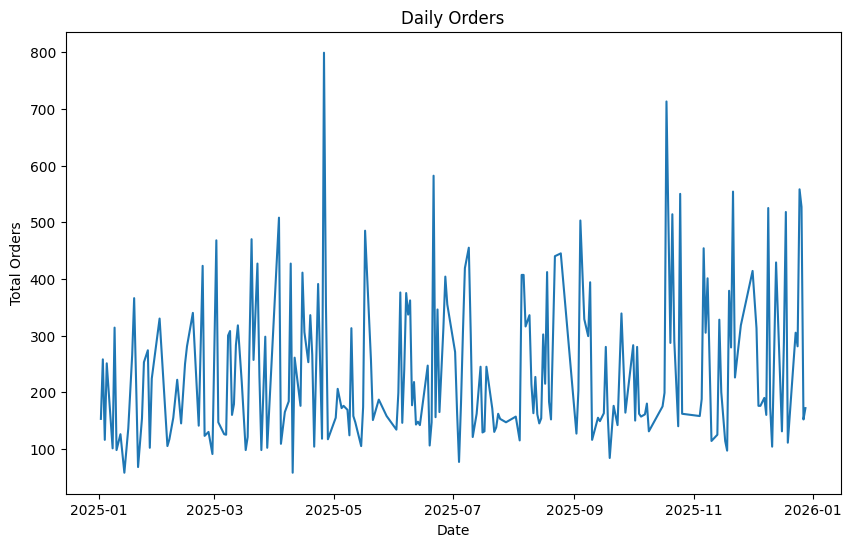

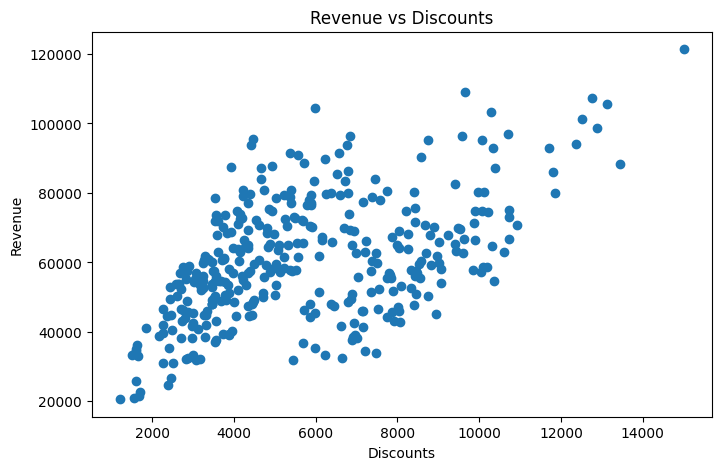

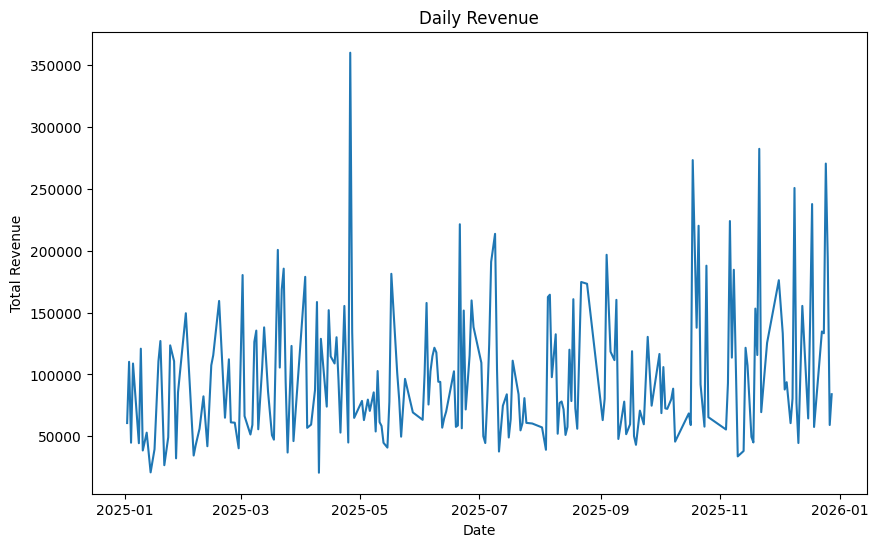

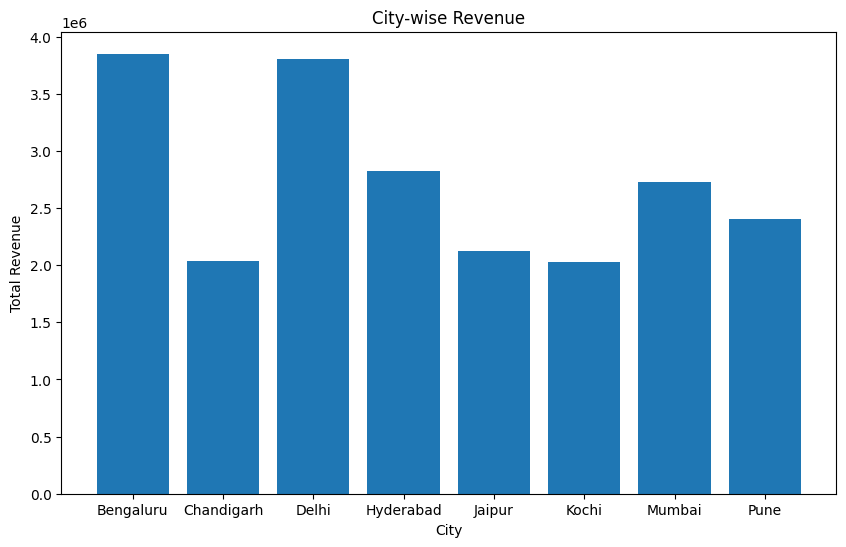

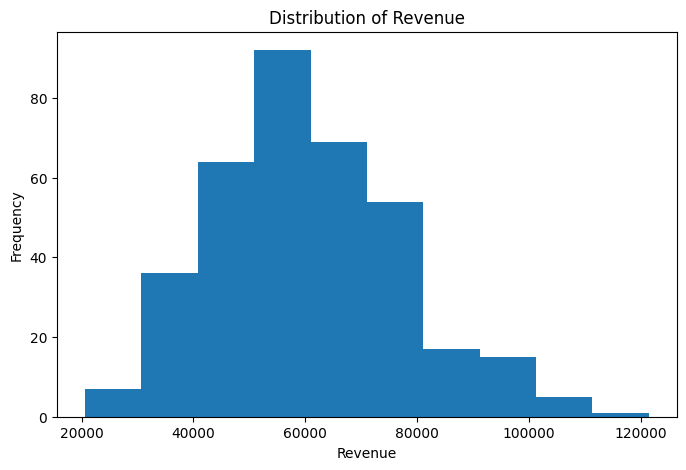

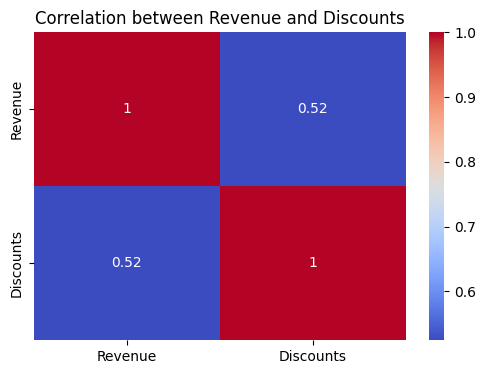

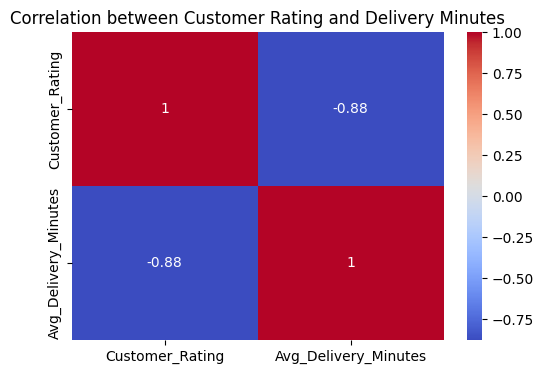

In [4]:

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("/content/Food_Delivery_Visualization_Dataset.csv")


# ============================================
# 2. BASIC DATA EXPLORATION
# ============================================

# Display first 2 rows
print(df.head(2))

# Check total missing values
print("Total Missing Values:", df.isnull().sum().sum())

# Check whether any missing value exists
print("Any Missing Values:", df.isnull().values.any())

# Display column names
print("Columns:")
print(df.columns)

# Display data types
print("Data Types:")
print(df.dtypes)

# Display information about dataset
df.info()

# Statistical summary
print(df.describe())

# Display number of rows and columns
print("Shape:", df.shape)

# Display last 5 rows
print(df.tail())

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())


# ============================================
# 3. DATA TYPE CONVERSION
# ============================================

# Convert Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'])

# List of numerical columns
numeric_columns = [
    "Orders",
    "Average_Order_Value",
    "Revenue",
    "Marketing_Spend",
    "Discounts",
    "Avg_Delivery_Minutes",
    "Customer_Rating",
    "Repeat_Customer_Percent"
]

# Convert numerical columns to numeric datatype
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col])


# ============================================
# 4. DAILY ORDERS
# ============================================

# Group orders by date and calculate total orders
daily_orders = df.groupby('Date')['Orders'].sum()

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot daily orders
ax.plot(daily_orders)

# Add labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Total Orders')
ax.set_title('Daily Orders')

# Display graph
plt.show()

# ============================================
# 8. SCATTERPLOT: REVENUE VS DISCOUNTS
# ============================================

fig, ax = plt.subplots(figsize=(8, 5))

# Create scatterplot
ax.scatter(df['Discounts'], df['Revenue'])

# Add labels and title
ax.set_xlabel('Discounts')
ax.set_ylabel('Revenue')
ax.set_title('Revenue vs Discounts')

plt.show()

# ============================================
# 5. DAILY REVENUE
# ============================================

# Group revenue by date and calculate total revenue
total_revenue = df.groupby('Date')['Revenue'].sum()

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot daily revenue
ax.plot(total_revenue)

# Add labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Total Revenue')
ax.set_title('Daily Revenue')

# Display graph
plt.show()


# ============================================
# 6. CITY-WISE REVENUE
# ============================================

# Group revenue by city
city_revenue = df.groupby('City')['Revenue'].sum()

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar chart
ax.bar(city_revenue.index, city_revenue.values)

# Add labels and title
ax.set_xlabel('City')
ax.set_ylabel('Total Revenue')
ax.set_title('City-wise Revenue')

# Display graph
plt.show()


# ============================================
# 7. REVENUE DISTRIBUTION - HISTOGRAM
# ============================================

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 5))

# Create histogram
ax.hist(df['Revenue'], bins=10)

# Add labels and title
ax.set_xlabel('Revenue')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Revenue')

# Display graph
plt.show()


# ============================================
# 8. CORRELATION: REVENUE VS DISCOUNTS
# ============================================

# Calculate correlation
corr = df[['Revenue', 'Discounts']].corr()

# Create figure and axes
fig, ax = plt.subplots(figsize=(6, 4))

# Create heatmap
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    ax=ax
)

# Add title
ax.set_title('Correlation between Revenue and Discounts')

# Display heatmap
plt.show()


# ============================================
# 9. CORRELATION: CUSTOMER RATING VS
#    DELIVERY MINUTES
# ============================================

# Calculate correlation
corr = df[['Customer_Rating', 'Avg_Delivery_Minutes']].corr()

# Create figure and axes
fig, ax = plt.subplots(figsize=(6, 4))

# Create heatmap
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    ax=ax
)

# Add title
ax.set_title('Correlation between Customer Rating and Delivery Minutes')

# Display heatmap
plt.show()

